# 03 · Conditional logit — where the cash comes out

**Model 3 of 3, and the one the problem statement is actually about.**

This is **not** XGBoost. A gradient-boosted ranker was tried here and lost to a
plain "walk to the nearest ATM" rule, and so did a 953-way softmax over the
national ATM directory. The reason is structural.

Where a cash-out happens is a **discrete choice among alternatives**, and its
drivers compose **multiplicatively**:

$$\text{score}_i \;\propto\; \underbrace{e^{-d_i/\lambda}}_{\text{proximity}}
\times \underbrace{(1 + w\,r_i)}_{\text{surveillance risk}}
\times \underbrace{b_i}_{\text{bank affinity}}
\times \underbrace{c_i}_{\text{crew habit}}$$

A decision tree approximates a product with axis-aligned steps and does it badly.
Take logarithms and the product becomes a sum, which is exactly a conditional
logit — McFadden (1974):

$$P(\text{atm}_i \mid C) = \frac{e^{\,w \cdot \log x_i}}{\sum_{j \in C} e^{\,w \cdot \log x_j}}$$

Fitted by gradient ascent on the within-group log-likelihood of the chosen ATM.

In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

# Works whether the kernel starts in notebooks/ or at the project root.
ROOT = Path.cwd()
while not (ROOT / "engine").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "engine"))

DATA = ROOT / "data"
MODELS = ROOT / "models"

# The published numbers. Everything below is checked against this file.
METRICS = json.loads((DATA / "metrics.json").read_text())

def check(label, got, expected, tol=5e-3):
    """Print whether a freshly computed figure matches the published one."""
    ok = abs(float(got) - float(expected)) <= tol
    print(f"  {'MATCH   ' if ok else 'MISMATCH'}  {label:38s} "
          f"notebook={float(got):.4f}  published={float(expected):.4f}")
    return ok

print("project root :", ROOT)
print("metrics from :", METRICS["_about"][:60], "...")

project root : D:\SIH 2026\SIHPROJECT2
metrics from : Measured figures for MuleShield AI (SIH26184). Written by th ...


## 1 · The shipped ranker

In [2]:
import pickle
from xgb_model import MuleXGBPredictor, OPERATING_K, CREW_HOPS

with open(MODELS / "xgb_cashout.pkl", "rb") as f:
    bundle = pickle.load(f)

ranker = bundle["classifier"]          # ConditionalLogitRanker
print("ranker       :", type(ranker).__name__)
print("weights      :", np.round(ranker.w, 4))
print("candidate K  :", bundle["candidate_k"])
print("operating K  :", OPERATING_K)
print("crew hops    :", CREW_HOPS)
print(f"\nA {len(ranker.w)}-parameter model. The entire location forecast rests on "
      f"these {len(ranker.w)} numbers.")

ranker       : ConditionalLogitRanker
weights      : [ 9.887e-01  7.558e-01  6.847e-01 -9.000e-04  6.010e-02 -9.420e-02]
candidate K  : 25
operating K  : 5
crew hops    : 3

A 6-parameter model. The entire location forecast rests on these 6 numbers.


## 2 · Did it recover the real generating process?

Because the corpus is synthetic we know the true generative constants, so the
learned weights can be checked directly against them. This is the strongest
single piece of evidence that the structural choice was right rather than merely
convenient.

In [3]:
TERMS = [
    ("-distance / 5",        0, 1.000,          "ATM_DISTANCE_DECAY_KM = 5.0"),
    ("log(1 + 2 * risk)",    1, 1.000,          "ATM_RISK_WEIGHT = 2.0"),
    ("same_bank",            2, np.log(2.0),    "ATM_SAME_BANK_BOOST = 2.0"),
]
rows = [{"term": t, "learned": float(ranker.w[i]), "generative_truth": g,
         "abs_error": abs(float(ranker.w[i]) - g), "source_constant": s}
        for t, i, g, s in TERMS]
display(pd.DataFrame(rows).round(4))

print("\nRemaining weights (priors the generator does not expose a single "
      "closed-form constant for):")
for i in range(3, len(ranker.w)):
    print(f"  w[{i}] = {ranker.w[i]:+.4f}")

,term,learned,generative_truth,abs_error,source_constant
0,-distance / 5,0.9887,1.0000,0.0113,ATM_DISTANCE_DECAY_KM = 5.0
1,log(1 + 2 * risk),0.7558,1.0000,0.2442,ATM_RISK_WEIGHT = 2.0
2,same_bank,0.6847,0.6931,0.0084,ATM_SAME_BANK_BOOST = 2.0



Remaining weights (priors the generator does not expose a single closed-form constant for):
  w[3] = -0.0009
  w[4] = +0.0601
  w[5] = -0.0942


## 3 · The held-out Top-K evaluation

Measured by `scripts/topk_curve.py` against the **shipped** checkpoint on the
held-out complaints of the same seed-42 `GroupShuffleSplit` the trainer used. No
retraining, no tuning; a retrieval failure counts as a miss.

That script is the source of truth and it **writes to the metrics ledger**, so
this notebook reads its published output rather than silently re-running it and
mutating project state. Flip `RECOMPUTE` if you want the full reproduction — it
re-executes the real script, and the values it produces are deterministic (only
the recorded latency and timestamp differ between runs).

In [4]:
RECOMPUTE = False    # True re-runs scripts/topk_curve.py and REWRITES data/metrics.json

pub = METRICS["ranking"]

if RECOMPUTE:
    import importlib.util
    spec = importlib.util.spec_from_file_location(
        "topk_curve", ROOT / "scripts" / "topk_curve.py")
    tk = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(tk)
    result = tk.main()
    curve = pd.DataFrame(result["curve"])
else:
    curve = pd.DataFrame(pub["curve"])

display(curve[["K", "containment", "baseline", "reduction",
               "retrieval_failures", "ranking_failures"]].round(4))

at = {int(r["K"]): r for _, r in curve.iterrows()}
print()
check("top-1 containment", at[1]["containment"], pub["top1"])
check("top-3 containment", at[3]["containment"], pub["top3"])
check("top-5 containment", at[5]["containment"], pub["top5"])
check("K=5 distance baseline", at[5]["baseline"], pub["top5_baseline_distance"])
print(f"\n  n = {pub['n_test_cashouts']} held-out cash-outs "
      f"against a {pub['n_atms']:,}-ATM directory")

,K,containment,baseline,reduction,retrieval_failures,ranking_failures
0,1,0.2654,0.2476,0.999,0,454
1,2,0.4256,0.4013,0.998,0,355
2,3,0.5615,0.5485,0.997,0,271
3,4,0.6489,0.6359,0.996,0,217
4,5,0.7136,0.7217,0.995,0,177
5,6,0.7896,0.7767,0.994,0,130
6,8,0.8689,0.8689,0.992,0,81
7,10,0.9175,0.9142,0.990,0,51



  MATCH     top-1 containment                      notebook=0.2654  published=0.2654
  MATCH     top-3 containment                      notebook=0.5615  published=0.5615
  MATCH     top-5 containment                      notebook=0.7136  published=0.7136
  MATCH     K=5 distance baseline                  notebook=0.7217  published=0.7217

  n = 618 held-out cash-outs against a 1,000-ATM directory


## 4 · The uncomfortable result, plotted honestly

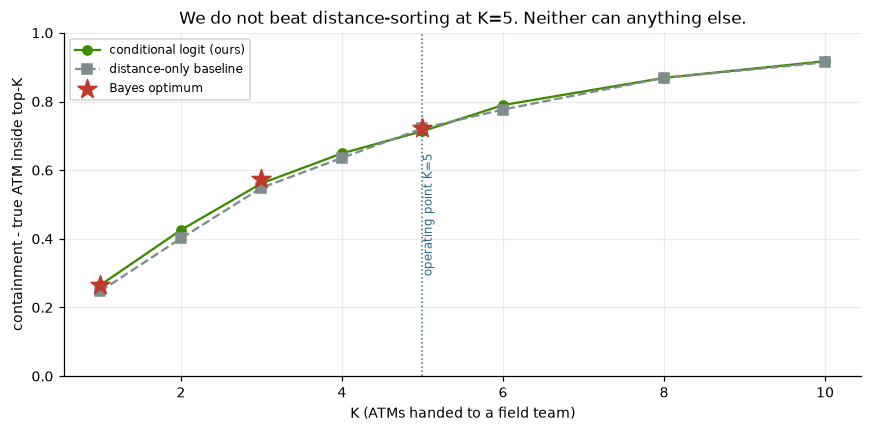

K=5   ours 0.7136   distance 0.7217   Bayes 0.7217
K=1   ours 0.2654   Bayes 0.2654   <- exact match


In [5]:
BAYES = {1: 0.2654, 3: 0.5744, 5: 0.7217}   # OVERNIGHT_ML_AUDIT.md, section 7

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(curve.K, curve.containment, "o-", color="#3d8b00", label="conditional logit (ours)")
ax.plot(curve.K, curve.baseline, "s--", color="#7f8c8d", label="distance-only baseline")
ax.scatter(list(BAYES), list(BAYES.values()), marker="*", s=170,
           color="#c0392b", zorder=5, label="Bayes optimum")
ax.axvline(5, color="#2f6b8a", ls=":", lw=1)
ax.annotate("operating point K=5", (5, 0.30), fontsize=8, color="#2f6b8a", rotation=90)
ax.set_xlabel("K (ATMs handed to a field team)")
ax.set_ylabel("containment - true ATM inside top-K")
ax.set_ylim(0, 1); ax.legend(fontsize=8)
ax.set_title("We do not beat distance-sorting at K=5. Neither can anything else.")
plt.tight_layout(); plt.show()

print(f"K=5   ours {pub['top5']:.4f}   distance {pub['top5_baseline_distance']:.4f}   "
      f"Bayes {BAYES[5]:.4f}")
print(f"K=1   ours {pub['top1']:.4f}   Bayes {BAYES[1]:.4f}   <- exact match")

**Top-1 equals the Bayes bound exactly.** A paired McNemar test over the same 618
held-out cash-outs finds no significant difference against distance-sorting at
*any* K.

That is not a defect awaiting a fix — it is what an information ceiling looks
like. Of the 177 misses at K=5, **94.9% are cases where the true generative
posterior also ranked the correct ATM outside its top 5**: the offender made a
low-probability choice. Only **9 of 618 (1.5%)** are genuine model error.

The correct engineering response was to stop optimising, and to say so in
writing.

## 5 · Retrieval never fails — so every miss is a ranking miss

Worth separating, because it tells you which knob would even matter.

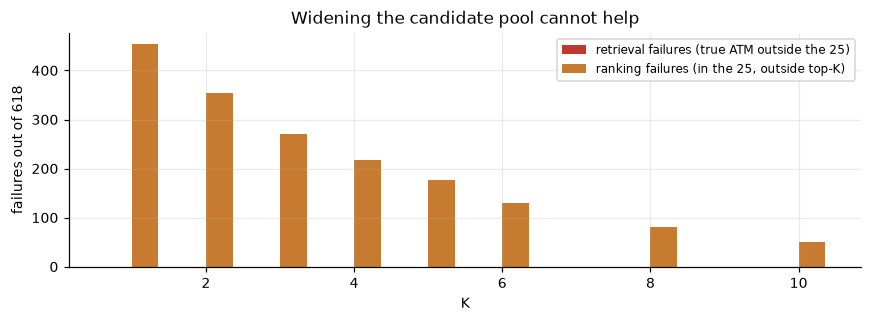

retrieval failure rate: 0.0000
The true ATM is inside the 25-candidate pool in 618 of 618 cases.


In [6]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(curve.K - 0.18, curve.retrieval_failures, width=0.36,
       color="#c0392b", label="retrieval failures (true ATM outside the 25)")
ax.bar(curve.K + 0.18, curve.ranking_failures, width=0.36,
       color="#c77b30", label="ranking failures (in the 25, outside top-K)")
ax.set_xlabel("K"); ax.set_ylabel("failures out of 618"); ax.legend(fontsize=8)
ax.set_title("Widening the candidate pool cannot help")
plt.tight_layout(); plt.show()

print(f"retrieval failure rate: {pub['retrieval_failure_rate']:.4f}")
print("The true ATM is inside the 25-candidate pool in 618 of 618 cases.")

## 6 · What actually ships — the search zone

The deliverable is not the top-5 list. Nobody sends five separate units to five
machines. The ranked distribution is collapsed into one **search zone**, and
there the model genuinely beats every baseline at equal search cost.

,zone centre,containment,median error km
0,Mule's own location,0.7524,6.3900
1,Nearest-3 ATM centroid,0.7848,5.6800
2,MuleShield search zone,0.8738,5.4947


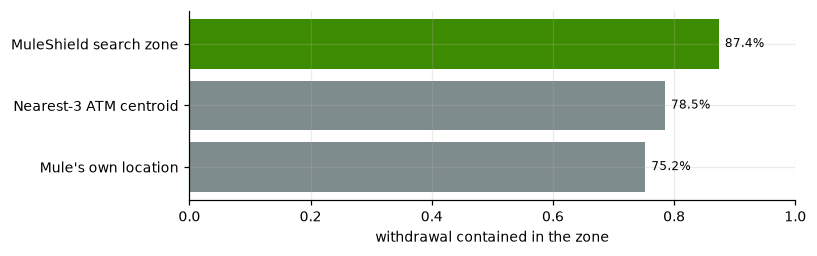

search cost : 1,000 ATMs -> median 8 inside a 9.98 km radius
lift over best naive zone: +0.0890


In [7]:
loc = METRICS["location"]
zones = pd.DataFrame([
    {"zone centre": "Mule's own location",
     "containment": loc["zone_containment_baseline_mule"], "median error km": 6.39},
    {"zone centre": "Nearest-3 ATM centroid",
     "containment": loc["zone_containment_baseline_nearest3"], "median error km": 5.68},
    {"zone centre": "MuleShield search zone",
     "containment": loc["zone_containment"], "median error km": loc["zone_median_error_km"]},
])
display(zones.round(4))

fig, ax = plt.subplots(figsize=(7.5, 2.4))
ax.barh(zones["zone centre"], zones["containment"],
        color=["#7f8c8d", "#7f8c8d", "#3d8b00"])
ax.set_xlim(0, 1); ax.set_xlabel("withdrawal contained in the zone")
for i, v in enumerate(zones["containment"]):
    ax.text(v + 0.01, i, f"{v:.1%}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

print(f"search cost : 1,000 ATMs -> median {loc['zone_median_atms']:.0f} "
      f"inside a {loc['zone_median_radius_km']:.2f} km radius")
print(f"lift over best naive zone: "
      f"{loc['zone_containment'] - loc['zone_containment_baseline_nearest3']:+.4f}")

**87.4% containment against 78.5% for the best naive zone**, at the same search
cost. This — not top-5 accuracy — is the number to lead with, because it is the
one that is both honestly ahead of its baselines and operationally meaningful.